# Explainable AI-Based Credit Risk Assessment & Credit Scoring System

## Import Libraries

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import joblib

## Import Data

In [2]:
df = pd.read_csv("../data/raw/UCI_Credit_Card.csv")

## Data Inspection
- To understand:
    - Data types
    - Number of features
    - Presence of null values
    - Statistical distribution
- Helps identify preprocessing needs early.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [4]:
df

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,1,3,1,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,1,3,2,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,1,2,2,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,1,3,1,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [5]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


## Missing Value Check
**Reason:**\
To ensure data integrity, improve model accuracy, and prevent biased, unreliable, or misleading conclusions. Unhandled missing data can cause machine learning algorithms to fail or produce poor predictions, while also reducing the statistical power and validity of research

In [6]:
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

**Observation:** No missing values found in the dataset. \
**Conclusion:** No imputation is required, simplifying preprocessing.

## Rename Target Variable
**Reason:**
- The original name is long and inconvenient.
- Improves clarity and code readability.

In [7]:
df.rename(columns={"default.payment.next.month": "default"}, inplace=True)

## Drop Irrelevant Feature
**Reason:**
- `ID` is a unique identifier.
- Doesn't contribute to prediction --> may introduce noise.

In [8]:
df.drop(columns=["ID"], inplace=True)

## Handling Incorrect Categorical Values
**Problem:**\ Some categorical comlumns contain invalid or undefined values.\
`EDUCATION`: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)\
`MARRIAGE`: Marital status (1=married, 2=single, 3=others)\

**Reason:**
- Values like 0, 5, 6 in `EDUCATION` are undocumented.
- Grouping them into a common category avoids:
    - Data inconsistency
    - Model confusion

In [9]:
# Problem
print(df["EDUCATION"].value_counts())
print(df["MARRIAGE"].value_counts())

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64
MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64


In [10]:
# Fix
df["EDUCATION"] = df["EDUCATION"].replace({0:4, 5:4, 6:4})
df["MARRIAGE"] = df["MARRIAGE"].replace({0:3})

## Identify Categorical Column

In [11]:
df[["SEX", "EDUCATION", "MARRIAGE"]]

,SEX,EDUCATION,MARRIAGE
0,2,2,1
1,2,2,2
2,2,2,2
3,2,2,1
4,1,2,1
...,...,...,...
29995,1,3,1
29996,1,3,2
29997,1,2,2
29998,1,3,1


**Issue:** They are numerically encoded but not ordinal.\
**Reason:** Treating them as numeric would mislead models into assuming order.

## Encode Categorical Values
- Converts categories into binary columns.
- Prevents models from assuming false relationships.
- `drop_first=True` avoids multicollinearity (dummy variable trap).

In [12]:
df = pd.get_dummies(df, columns=["SEX", "EDUCATION", "MARRIAGE"])

## Feature Engineering
- Aggregated features capture overall financial behavior.
- Often improve predictive performance.

In [13]:
df["TOTAL_BILL"] = df[[f"BILL_AMT{i}" for i in range(1,7)]].sum(axis=1)
df["TOTAL_PAY"] = df[[f"PAY_AMT{i}" for i in range(1,7)]].sum(axis=1)
df['DUE_BALANCE'] = df['TOTAL_BILL'] - df['TOTAL_PAY']

**Report**\
A new feature named DUE_BALANCE was created to represent the outstanding amount owed by the customer. It is calculated as the difference between total billed amount and total repayment. This feature provides a meaningful indicator of financial behavior and helps improve the predictive capability of the model.

In [14]:
df

,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,...,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3,TOTAL_BILL,TOTAL_PAY,DUE_BALANCE
0,20000.0,24,2,2,-1,-1,-2,-2,3913.0,3102.0,...,False,True,False,False,True,False,False,7704.0,689.0,7015.0
1,120000.0,26,-1,2,0,0,0,2,2682.0,1725.0,...,False,True,False,False,False,True,False,17077.0,5000.0,12077.0
2,90000.0,34,0,0,0,0,0,0,29239.0,14027.0,...,False,True,False,False,False,True,False,101653.0,11018.0,90635.0
3,50000.0,37,0,0,0,0,0,0,46990.0,48233.0,...,False,True,False,False,True,False,False,231334.0,8388.0,222946.0
4,50000.0,57,-1,0,-1,0,0,0,8617.0,5670.0,...,False,True,False,False,True,False,False,109339.0,59049.0,50290.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,39,0,0,0,0,0,0,188948.0,192815.0,...,False,False,True,False,True,False,False,725349.0,42550.0,682799.0
29996,150000.0,43,-1,-1,-1,-1,0,0,1683.0,1828.0,...,False,False,True,False,False,True,False,21182.0,14490.0,6692.0
29997,30000.0,37,4,3,2,-1,0,0,3565.0,3356.0,...,False,True,False,False,False,True,False,70496.0,31300.0,39196.0
29998,80000.0,41,1,-1,0,0,0,-1,-1645.0,78379.0,...,False,False,True,False,True,False,False,266611.0,147181.0,119430.0


## Key Fearture Plots

<Axes: xlabel='default', ylabel='TOTAL_BILL'>

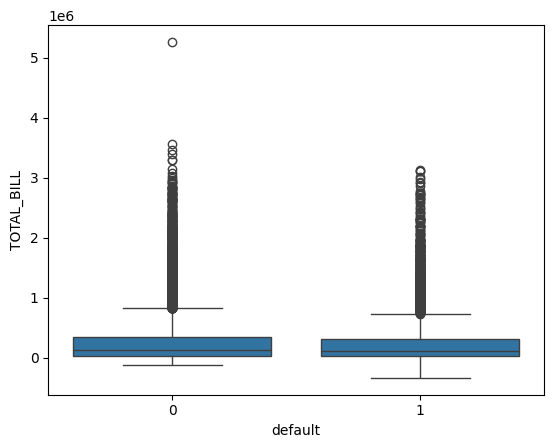

In [15]:
sns.boxplot(x='default', y='TOTAL_BILL', data=df)

<Axes: xlabel='default', ylabel='TOTAL_PAY'>

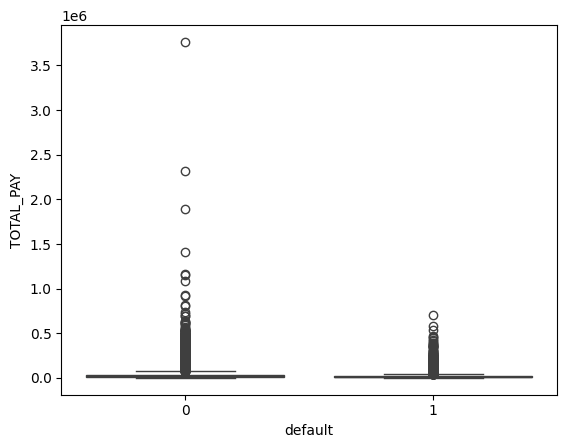

In [16]:
sns.boxplot(x='default', y='TOTAL_PAY', data=df)

<Axes: xlabel='default', ylabel='DUE_BALANCE'>

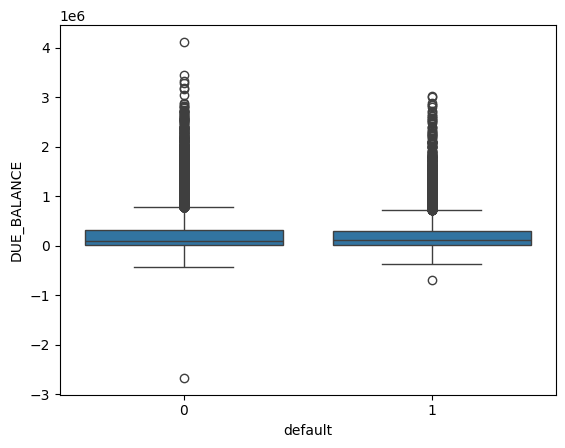

In [17]:
sns.boxplot(x='default', y='DUE_BALANCE', data=df)

<Axes: xlabel='default', ylabel='LIMIT_BAL'>

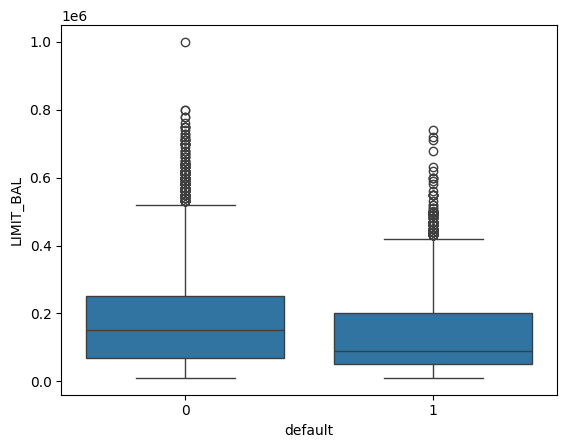

In [18]:
sns.boxplot(x='default', y='LIMIT_BAL', data=df)

<Axes: xlabel='PAY_0', ylabel='count'>

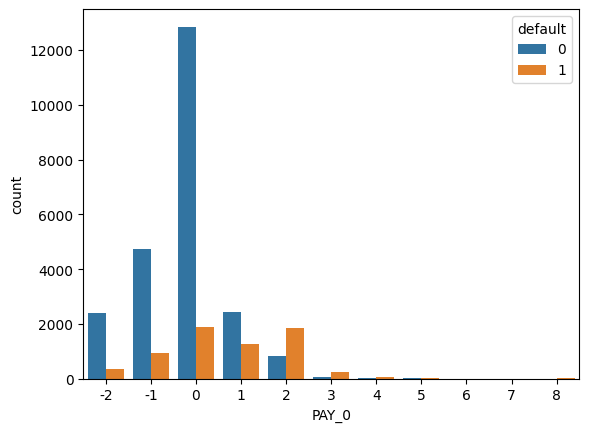

In [19]:
sns.countplot(x='PAY_0', hue='default', data=df)

<Axes: xlabel='AGE', ylabel='count'>

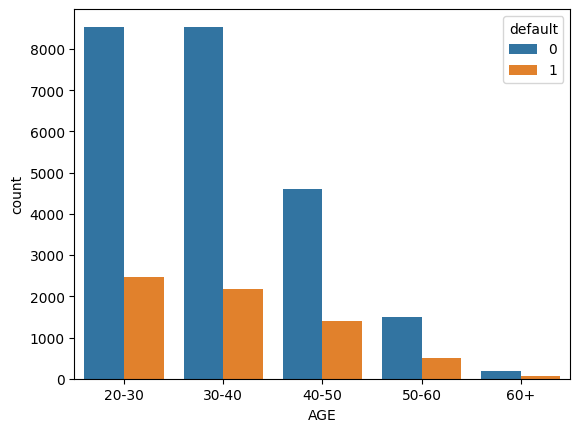

In [20]:
age_bins = pd.cut(
    df['AGE'],
    bins=[20, 30, 40, 50, 60, 80],
    labels=['20-30', '30-40', '40-50', '50-60', '60+']
)

sns.countplot(x=age_bins, hue=df['default'])

## Feature Scaling
- Features like `LIMIT_BAL` and `TOTAL_BILL` have large ranges.
- Scaling ensures:
    - Faster convergence
    - Equal importance across features

In [21]:
scaler = StandardScaler()
num_cols = ["LIMIT_BAL", "AGE", "PAY_0", "PAY_2", "PAY_3", "TOTAL_PAY", "TOTAL_BILL"]

df[num_cols] = scaler.fit_transform(df[num_cols])

In [22]:
joblib.dump(scaler, "../bin/scaler.pkl")

['../bin/scaler.pkl']

## Outlier Treatment
- Financial datasets often contain extreme values.
- Outliers can:
    - Skew model learning
    - Reduce accuracy
- Clipping limits their impact without removing data.

In [23]:
for col in ["BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6"]:
    df[col] = df[col].clip(
        lower=df[col].quantile(0.01),
        upper=df[col].quantile(0.99)
    )

## Save Processed Data

In [24]:
df.to_csv("../data/processed/cleaned_data.csv", index=False)